In [9]:
import pandas as pd

# Avec plus d'options
df = pd.read_csv(
    'donnees.txt',
    sep='\t',
    skipinitialspace=True,  # Ignore les espaces après le séparateur
)

df

,Vitess_Vent_[m/s],Dir_Vent_[deg],Pelec[w],Patm[Pa],Temp[degC],Statut
0,4.4,221,35857,100782,-1.2,1
1,8.1,325,228431,101925,2.5,1
2,1.6,14,0,102126,7.5,1
3,1.3,235,0,100436,-1.3,0
4,3.0,80,0,100317,14.4,1
...,...,...,...,...,...,...
19913,14.3,166,1239022,101419,7.8,1
19914,4.3,184,34445,101390,4.6,1
19915,11.5,169,660867,101521,0.6,1
19916,5.2,18,58428,100440,5.9,1


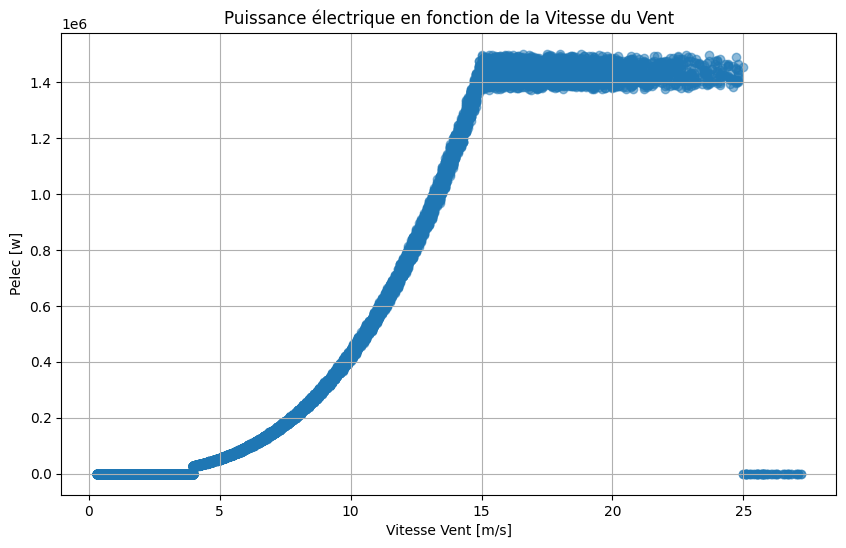

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(df['Vitess_Vent_[m/s]'], df['Pelec[w]'], alpha=0.5)
plt.xlabel('Vitesse Vent [m/s]')
plt.ylabel('Pelec [w]')
plt.title('Puissance électrique en fonction de la Vitesse du Vent')
plt.grid(True)
plt.show()

In [11]:
# Moyenne de la puissance électrique pour chaque vitesse du vent
moyenne_par_vitesse = (
    df.groupby('Vitess_Vent_[m/s]')['Pelec[w]']
      .mean()
      .reset_index()
      .rename(columns={'Pelec[w]': 'Pelec_moy[w]'})
      .sort_values('Vitess_Vent_[m/s]')
)

# Arrondi uniquement pour l'affichage (le groupby reste basé sur les valeurs originales)
moyenne_par_vitesse_display = moyenne_par_vitesse.copy()
moyenne_par_vitesse_display['Vitess_Vent_[m/s]'] = moyenne_par_vitesse_display['Vitess_Vent_[m/s]'].round(2)
moyenne_par_vitesse_display['Pelec_moy[w]'] = moyenne_par_vitesse_display['Pelec_moy[w]'].round(2)

moyenne_par_vitesse_display

,Vitess_Vent_[m/s],Pelec_moy[w]
0,0.3,0.0
1,0.4,0.0
2,0.5,0.0
3,0.6,0.0
4,0.7,0.0
...,...,...
262,26.7,0.0
263,26.8,0.0
264,27.0,0.0
265,27.1,0.0


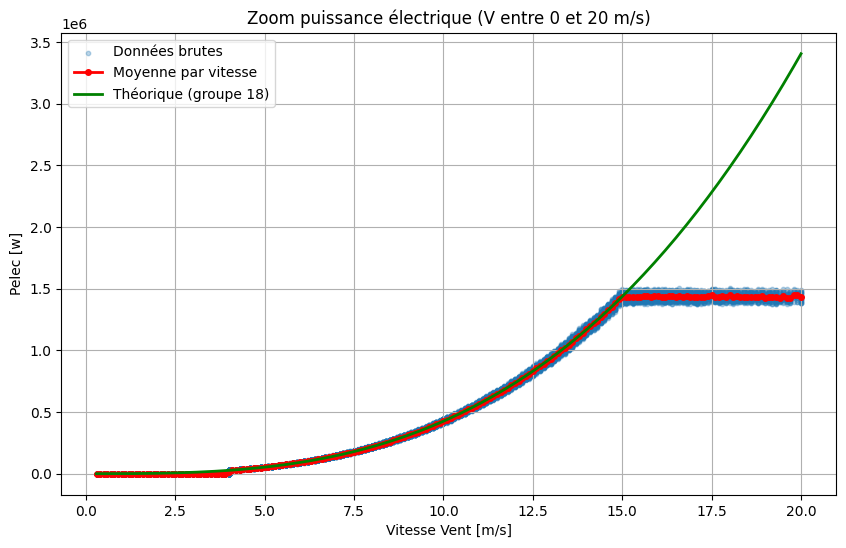

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# Zoom : vitesses entre 0 et 20 m/s
v_min, v_max = 0, 20

# Paramètres du groupe 18
# (Dans la table fournie : D = 60 m)
groupe = 18
D = 60  # m
eta = 0.2  # a ajuster si votre énoncé donne une autre valeur

# Masse volumique moyenne (gaz parfait)
Ru = 8.314462618  # J/(mol.K)
M_air = 0.02897  # kg/mol (air ~ 28.97 g/mol)
rho_moy = (df['Patm[Pa]'] * M_air / (Ru * (df['Temp[degC]'] + 273.15))).mean()

# Filtrer les données brutes
mask_raw = (df['Vitess_Vent_[m/s]'] >= v_min) & (df['Vitess_Vent_[m/s]'] <= v_max)
df_zoom = df.loc[mask_raw]

# Courbe moyenne (et théorie) zoomée
moy_zoom = moyenne_par_vitesse[
    (moyenne_par_vitesse['Vitess_Vent_[m/s]'] >= v_min) &
    (moyenne_par_vitesse['Vitess_Vent_[m/s]'] <= v_max)
].copy()

v_moy = moy_zoom['Vitess_Vent_[m/s]'].values
A = np.pi * (D**2) / 4
P_theorique_zoom = eta * (16 / 27) * rho_moy * (v_moy**3) * A

plt.figure(figsize=(10, 6))

# Données brutes
plt.scatter(
    df_zoom['Vitess_Vent_[m/s]'],
    df_zoom['Pelec[w]'],
    alpha=0.3,
    s=10,
    label='Données brutes'
)

# Moyennes par vitesse
plt.plot(
    moy_zoom['Vitess_Vent_[m/s]'],
    moy_zoom['Pelec_moy[w]'],
    color='red',
    marker='o',
    linewidth=2,
    markersize=4,
    label='Moyenne par vitesse'
)

# Théorie superposée
plt.plot(
    v_moy,
    P_theorique_zoom,
    color='green',
    linewidth=2,
    label=f'Théorique (groupe {groupe})'
)

plt.xlabel('Vitesse Vent [m/s]')
plt.ylabel('Pelec [w]')
plt.title('Zoom puissance électrique (V entre 0 et 20 m/s)')
plt.grid(True)
plt.legend()
plt.show()